# What We Didn't Use, and Why

An analysis is defined as much by what it refuses to claim as by what it asserts. Over the course of this project we tested roughly a dozen hypotheses; four survived scrutiny and became the chapters above. This final chapter is an honest accounting of the rest — the tempting patterns that didn't hold up, and the limits of the data itself.

This is not a confession of failure. Discarding a finding that doesn't survive testing is the work, not a detour from it. Each result below was set aside for a specific, identifiable reason — a confound, a fragile sample, a measurement that turned out to be hollow — and naming those reasons is what gives the surviving four their weight. A report that claimed all twelve would be less trustworthy, not more.

In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

import _style
_style.set_style()

reviews = pd.read_parquet("../data/processed/reviews.parquet")
metadata = pd.read_parquet("../data/processed/metadata.parquet")
print(f"{len(reviews):,} reviews · {len(metadata)} games")

298,553 reviews · 50 games


## The finding that looked best and held up worst: Early Access

The most dramatic pattern we found was also the most misleading. Reviews written while a game was still in Early Access recommend at **44.8%** — against an **87%** baseline for everything else. A 42-point collapse. As a headline, *"reviewing an unfinished game makes players harsh"* is irresistible.

It is an artifact of which games, not when they were reviewed. Early Access reviews aren't spread across the catalog; they pile up in the handful of titles that had rough or prolonged Early Access periods — and those happened to be poorly received. The 44.8% measures the company those reviews keep, not the effect of reviewing early. When we apply the within-game test — comparing Early Access and post-launch reviews *of the same game* — only a single game in the set has enough of both to compare, and there the gap reverses. There is no within-game effect to find. We dropped it.

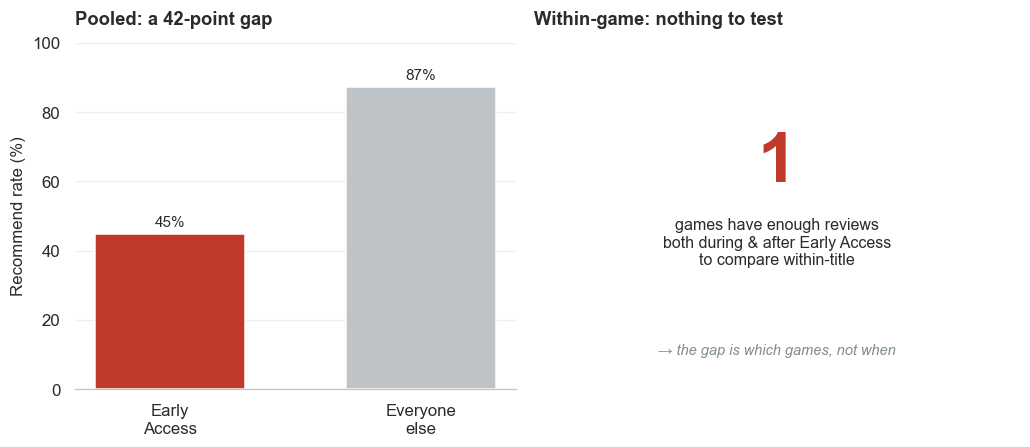

pooled EA 44.8% vs 87.2% · comparable games: 1


In [2]:
ea = reviews["written_during_early_access"] == True
pooled_ea = reviews.loc[ea, "voted_up"].mean() * 100
pooled_non = reviews.loc[~ea, "voted_up"].mean() * 100

# within-game comparability
def ea_ok(d):
    return (d["written_during_early_access"]==True).sum() >= 30 and (d["written_during_early_access"]==False).sum() >= 30
n_comparable = reviews.groupby("app_id").apply(ea_ok, include_groups=False).sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.2), gridspec_kw={"width_ratios":[1,1.1]})
ax1.bar(["Early\nAccess","Everyone\nelse"], [pooled_ea, pooled_non],
        color=[_style.ACCENT, _style.GREY], width=0.6)
ax1.bar_label(ax1.containers[0], fmt="%.0f%%", padding=3, fontsize=10)
ax1.set_ylim(0,100); ax1.set_ylabel("Recommend rate (%)")
ax1.set_title("Pooled: a 42-point gap", loc="left", fontsize=12)

ax2.text(0.5,0.60,f"{int(n_comparable)}",ha="center",fontsize=46,color=_style.ACCENT,
         fontweight="bold",transform=ax2.transAxes)
ax2.text(0.5,0.36,"games have enough reviews\nboth during & after Early Access\nto compare within-title",
         ha="center",fontsize=10.5,transform=ax2.transAxes)
ax2.text(0.5,0.10,"→ the gap is which games, not when",ha="center",fontsize=9.5,
         color=_style.GREY_DARK,style="italic",transform=ax2.transAxes)
ax2.axis("off"); ax2.set_title("Within-game: nothing to test", loc="left", fontsize=12)
plt.show()
print(f"pooled EA {pooled_ea:.1f}% vs {pooled_non:.1f}% · comparable games: {int(n_comparable)}")

## The review bomb we could see but couldn't prove

Some cuts are about confounds. This one is about the limits of our own data collection.

Among the games in the set, Helldivers 2 shows an unmistakable event: its daily recommend rate sits at **27%** at the start of our window in early May 2026 and climbs steadily back toward its usual ~85% over the following month. Something clearly happened — a sustained wave of negative sentiment, the signature of a review bomb in recovery.

And yet we decline to call it one. The reason is precise, and the chart shows it. A *review bomb* is a claim about **anomaly** — a spike that stands out against a game's normal pattern. But our window *begins* near the bottom of the event: we see the recovery, never the onset, and never the ordinary days before it. To call something anomalous you need the baseline it deviates from, and recency-limited collection cannot give us Helldivers 2's history before early May. We can show the dip and its healing; we cannot prove how unusual it was. The honest statement is "a sustained sentiment drop was in progress," not "a review bomb occurred." Detecting coordinated campaigns rigorously needs full-history, time-ordered collection — which the pipeline supports by configuration but this analysis did not use.

And yet we decline to call it one. The reason is precise. A *review bomb* is a claim about **anomaly** — a spike that stands out against a game's normal pattern. To establish anomaly, you need a baseline: the game's typical day-to-day sentiment over a long history. But we collected each game's *most recent* reviews, which for a title as active as Helldivers 2 reaches back only weeks. We can see the dip; we cannot prove it is unusual, because we have no long-run baseline to compare it against. The honest statement is "a sharp sentiment drop occurred," not "a review bomb occurred." Detecting coordinated campaigns rigorously needs full-history, time-ordered collection — a capability the pipeline supports by configuration but that this analysis did not use.

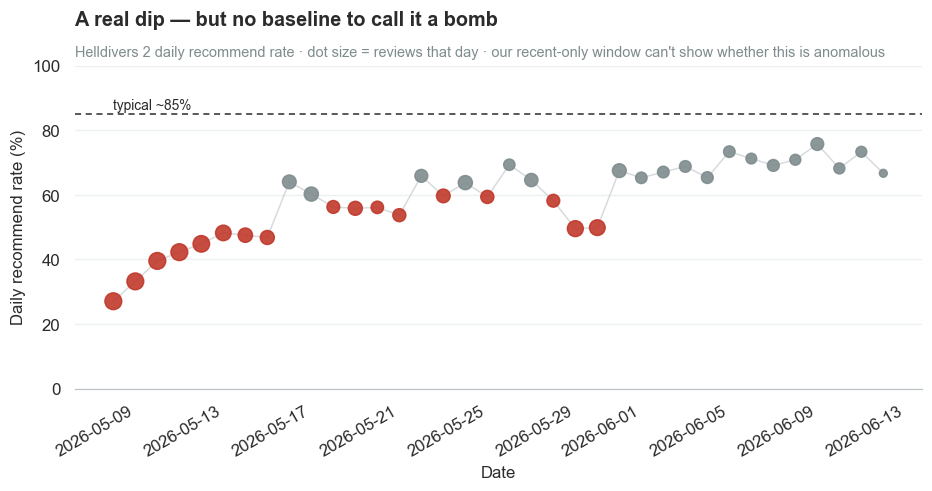

HD2 span: 2026-05-08 to 2026-06-12 (36 days)
lowest day: 27% · typical: ~85%


In [3]:
# The Helldivers 2 sentiment dip — real, but un-baselined
hd = reviews[reviews["app_id"] == 553850].copy()
hd["date"] = pd.to_datetime(hd["timestamp_created"]).dt.date
daily = hd.groupby("date").agg(n=("voted_up", "size"), rate=("voted_up", "mean"))
daily = daily[daily["n"] >= 10]   # days with enough reviews to be meaningful
daily["rate"] *= 100

fig, ax = plt.subplots(figsize=(9, 4.6))
# colour days below a threshold as the "event", rest grey
colors = [_style.ACCENT if r < 60 else _style.GREY_DARK for r in daily["rate"]]
ax.scatter(daily.index, daily["rate"], c=colors, s=[min(n/3, 120) for n in daily["n"]],
           zorder=3, alpha=0.9)
ax.plot(daily.index, daily["rate"], color=_style.GREY, linewidth=1, zorder=1, alpha=0.6)
ax.axhline(85, color=_style.INK, linestyle=(0,(4,3)), linewidth=1)
ax.text(daily.index[0], 86.5, "typical ~85%", fontsize=9, color=_style.INK)
ax.set_ylim(0, 100)
ax.set_ylabel("Daily recommend rate (%)")
ax.set_xlabel("Date")
ax.set_title("A real dip — but no baseline to call it a bomb\n", loc="left",
             fontsize=13, fontweight="bold")
ax.text(0, 1.02,
        "Helldivers 2 daily recommend rate · dot size = reviews that day · "
        "our recent-only window can't show whether this is anomalous",
        transform=ax.transAxes, fontsize=9.5, color=_style.GREY_DARK, va="bottom")
fig.autofmt_xdate()
plt.show()

print(f"HD2 span: {daily.index.min()} to {daily.index.max()} ({len(daily)} days)")
print(f"lowest day: {daily['rate'].min():.0f}% · typical: ~85%")

## Five more we set aside

The remaining cuts were quieter — weak signals, confounds, or variables that turned out hollow. Each is worth a sentence, because each was a real hypothesis honestly tested.

**Price.** Pricier games show a faint negative correlation with recommendation (Spearman ρ ≈ −0.30), but it rests on just 43 paid titles, it isn't monotonic, and it sits right at the edge of significance. With fifty games, one or two moving could erase it. Too fragile to claim.

**Critics versus players.** Metacritic score and player recommendation correlate moderately (ρ ≈ 0.62) — but they *agree*, and agreement isn't a story. The disagreements, where one might find something, are small and unsystematic. No finding worth a chapter.

**Language and sentiment.** Recommend rates differ by review language — but which language a review is written in is tangled up with which games that community plays. We cannot separate culture from catalog with this data, so we report the raw differences nowhere as a claim.

**Free copies.** Reviews from people who got a game free recommend at almost exactly the same rate as those who paid (≈83% vs 85%). A tidy natural experiment with a null result — and too few free-copy reviews to lean on regardless.

**The helpfulness score.** Steam's `weighted_vote_score` looked like a ready-made measure of review quality, until we found three-quarters of all reviews sit at the identical default value. A variable that is constant for most of the data can answer no question. We pivoted away from it entirely.

## Limits of the data itself

Beyond individual findings, four properties of how the data was collected bound what any of this can claim. They apply to the four surviving chapters as much as to the discarded ones.

**These are recent reviews, not full histories.** Each game's reviews were collected newest-first, up to 10,000 per title — a deliberate choice for reliable, reproducible, time-ordered collection, since Steam's relevance sort paginates unstably and skews toward already-popular reviews. The cost is reach: for heavily-reviewed games, ten thousand recent reviews span only weeks or months. This is why historical questions — review bombs, long-run sentiment trends — are out of range. It is a one-line configuration change to collect full histories instead; this analysis simply didn't need to.

**Half of all profiles are private.** Steam reports zero games owned for private profiles, and more than half of reviewers come back that way. Any analysis touching reviewer attributes (as the veteran chapter does) is restricted to the public-profile subset, and generalizes only with that caveat.

**This is observational, not experimental.** We watched reviews as they were written; we changed nothing. So we can establish that patterns exist and are robust, but causal language is always hedged. Where a tempting cause appears — the refund deadline, the burden of justification, the veteran's raised bar — we name the alternatives rather than assume our own.

**Fifty games is a deliberate sample, not the population.** Review-level findings rest on hundreds of thousands of rows and are strong. Game-level observations rest on fifty points and are treated as suggestive at most. The fifty were chosen for breadth, not randomness, so the findings describe these games well and the broader catalog only by inference.

## What comes next

Two themes run through everything set aside here. Several findings died because we lacked the *history* to baseline them. Several questions — above all, *why* negative reviews are longer — went unanswered because we deliberately analyzed the *structure* of reviews, not their *text*.

Both are signposts to later phases of this project.

A full-history, time-ordered collection — already supported by the pipeline's configuration — would turn the un-baselined review bomb into a measurable one, and open the door to genuine trend analysis.

And the review text itself, left untouched here, is the subject of the phases ahead. This phase asked what could be learned from the *shape* of a review — its timing, its length, its author. The next ask what the *words* add: whether negative reviews are longer because they carry more specific justification, whether sentiment can be read from language directly, how much the text reveals that structure alone cannot. The structured findings in this report are the baseline those models will be measured against.

What the score doesn't tell you, this report found in the structure around it. The rest is in the words — and that is where this project goes next.